# packed_v1 leaderboard — visual weigh-in

Focused view of the `packed_v1` regime (canonical 4k-step horizon).

Two views:
1. **σ-anchored leaderboard** (bar chart): mean ± std per (optimizer, rank) cell, with AdamW's multi-seed σ-band as the reference. Single-seed cells render without error bars.
2. **Trajectory panel** (`standard_sweep_figure`): eval-loss curves over training, with AdamW's seed=0 η-sweep as the left-panel reference.

**σ_AdamW(packed_v1):** 0.0011 at r=16, 0.0017 at r=64 (from `adamw_multiseed_packed_4k_blackwell`, 4 seeds at η=3e-4 + seed=0 lr-sweep). All Δ claims in the writeups should be quoted in σ-units against this anchor.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plot_utils import (
    DIVERGE_THRESHOLD, OPTIM_COLORS, OPTIM_MARKERS,
    standard_sweep_figure,
)
from lora_playground.loader import load_runs, inventory_runs, render_inventory

# Force re-parse of log files. The plot_utils cache keys runs by file
# (mtime, size); when the loader code changes (e.g., adding init_b
# backfill) the cached cfgs are stale even though the files haven't moved.
# Clear once on startup so the next load_runs call re-reads everything.
import lora_playground.plot_utils as _pu
_pu._LOAD_RUN_CACHE.clear()
_pu._LOAD_SWEEP_CACHE.clear()
print(f"Cleared run/sweep caches — load_runs will re-parse all log files.")

Cleared run/sweep caches — load_runs will re-parse all log files.


## Audit — what's loadable vs invisible

In [3]:
print(render_inventory(inventory_runs('../logs')))

Loaded 230 of 242 groups on disk.

NO run_info/ (15) — files present but missing run_info/ dir, invisible to load_runs:
  adamw_sanity_packed_v1_4k
  bench
  bench_a100
  bench_phase_L
  bench_profile_packed_v1
  bench_profile_walltime
  chord_direction_k3_lr5e-3_r16r64_blackwell.contaminated_v1
  chord_tight_k3_r16_lr6e-2_4k_blackwell.contaminated_v1
  chord_tight_k3_r64_lr1e-3_4k_blackwell.contaminated_v1
  ddp_smoke
  debug_snapshots
  integration_higham_test
  profile_polar_components
  r256_chord_direction_k1_lrsweep_4k_blackwell.contaminated_v1
  r256_chord_lr5e-3_refinement_blackwell.contaminated_v1

ALL RUNS EXCLUDED (21) — valid manifest + .out files, but every run dropped by exclusion chain:
  adamw_4k_rsweep: polar-k3 regression at r256 rerun / rsweep
  chord_tight_k3_eps_rel_1e-2_r16r64_lr_sweep_4k_blackwell: invariant lambda_max_fix_for_eps_rel: ε_rel runs require λ_max fix in Higham inv-sqrt damping path (commit 9677abe, 2026-05-13)
  chord_tight_k3_eps_rel_1e-2_r16r64_lr

## Load packed_v1 runs

Reference = AdamW lr-sweep (seed=0). Candidates = chord/polar variants at lr=3e-3.

In [4]:
# Reference: AdamW packed_v1, ALL seeds. The library aggregates per-η
# (left panel: vertical seed-σ error bars) and per-step at best η (right
# panel: shaded ±σ band around the mean trajectory). Partial-horizon runs
# are auto-filtered (`min_step` inferred from cfg.max_steps).
ref_runs = load_runs(
    where={'optimizer': 'adamw', 'data_pipeline_version': 'packed_v1',
           'max_steps': 4000},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'reference AdamW packed_v1 (all seeds): {len(ref_runs)} runs')
from collections import Counter
print(f'  seeds per η: ' + ', '.join(
    f"η={lr:.0e}:{n}" for lr, n in
    Counter(cfg['lr'] for cfg, _ in ref_runs).most_common()))

# Candidates: chord/polar family only.
# adam-muon-lora and muon-lora are excluded — at their best lr they sit
# ~+0.012 above AdamW (r=16) and ~+0.010 (r=64), far outside the chord
# variants' Δ range. Including them just stretches plot range / legend
# without informing the chord-vs-AdamW comparison.
CANDIDATE_FAMILY = [
    'adam-polar-product-lora-coupled-spectral-chord-tight',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening',
    'adam-polar-product-lora-coupled-spectral-chord-direction',
    'adam-polar-product-lora-coupled',  # frob (AdaMuon parent, no chord-tight ρ)
]
cand_runs = load_runs(
    where={'optimizer': CANDIDATE_FAMILY, 'data_pipeline_version': 'packed_v1',
           'max_steps': 4000},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'candidate packed_v1 @ 4k: {len(cand_runs)} runs')
for cfg, evs in cand_runs:
    last = evs[-1] if evs else {}
    pic = cfg.get('_derived', {}).get('effective_picard_iters')
    print(f"  {cfg['optimizer']:55s} r={cfg.get('lora_r')} lr={cfg.get('lr'):.0e} k={pic} "
          f"step={last.get('step')} eval={last.get('eval_loss'):.4f}")


/mnt/home/nghosh/miniforge3/envs/ffcv-pl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [loader] excluded 160 run(s): 11 for 'Superseded by later chord-tight runs at the same cfg; +0.01 above seed cluster. See log_00 entry.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_01.out, r64_chord_postfix_validation_4k_blackwell/log_02.out, r64_chord_postfix_validation_4k_blackwell/log_03.out, +8 more); 1 for 'Superseded by later chord-tight runs at the same cfg; runs systematically +0.01 above seed cluster from descendants of ef6b3bc. Legacy registry entry blanket-excluded commit 91122ce; we narrow to the affected group since the bug surface was specific to this validation sweep.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_00.out); 7 for 'buggy ε_rel (contam rerun cleanup, pre-λ_max-fix)' (e.g. eps_rel_lr_tuned_4k_blackwell/log_00.out, eps_rel_lr_tuned_4k_blackwell/log_01.out, eps_rel_lr_tuned_4k_blackwell/log_02.out, +4 more); 8 for 'buggy ε_rel (precond_delta_relative fix applied but pre-λ_max-fix (9677abe))' (e.g. chord_tight_k3_eps_rel_1e-2_r16r64_lr_sweep_4k_

## Group key and color map

For AdaMuon-parent runs (no chord-tight ρ), distinguish by Picard iter count to separate the `frob_k=1` and `frob_k=3` cells. For chord-family variants the optimizer slug alone is the discriminator.

In [5]:
# Short legend labels with explicit Picard k. Leaderboard now contains both
# k=1 and k=3 cells for the same optimizer slug — always embed k. Init[AB]
# (B initialized non-zero via PiSSA-style symmetric init) is tagged
# separately. Non-default damping (ε_rel-relative or non-1e-6 absolute)
# also gets a tag so eps_rel sweep runs don't silently merge with default-
# damping series at the same lr.
SHORT = {
    'adam-polar-product-lora-coupled-spectral-chord-tight':                'chord-tight',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening':   'chord-tight (no-whiten)',
    'adam-polar-product-lora-coupled-spectral-chord-direction':            'chord-direction',
}


# Pre-fix commits: every run with precond_delta_relative=True committed
# before EPS_REL_FIX_COMMIT actually applied ABSOLUTE δ damping (the
# kwarg was silently dropped on the way to the kernel). Relabel those
# cells so they show up as δ_abs in plots / leaderboard tags.
EPS_REL_FIX_COMMIT = 'ef6b3bc'
import subprocess as _sp
try:
    _r = _sp.run(['git', '-C', '/mnt/home/nghosh/lora', 'rev-list',
                  f'{EPS_REL_FIX_COMMIT}^'],
                 capture_output=True, text=True, check=True)
    _BUGGY_COMMITS = set(line.strip()[:7] for line in _r.stdout.splitlines()
                         if line.strip())
except Exception as _e:
    print(f'WARN: could not compute pre-fix commits: {_e}')
    _BUGGY_COMMITS = set()

def _damping_tag(cfg):
    """'' for default damping (δ=1e-6 absolute or unset). Tag for non-default.

    Reads cfg['precond_delta'] + cfg['precond_delta_relative'] which the
    generic CLI backfill in plot_utils._read_run populates from the logged
    command string. Pre-fix runs (commit < EPS_REL_FIX_COMMIT) silently
    applied ABSOLUTE damping despite the --precond_delta_relative flag — we
    re-tag them as δ_abs so plots reflect what the run actually computed."""
    pdr = bool(cfg.get('precond_delta_relative'))
    pd = cfg.get('precond_delta')
    if pd is None:
        return ''
    if pdr:
        commit = (cfg.get('git_commit') or '')[:7]
        if commit in _BUGGY_COMMITS:
            return f' [δ_abs={pd:g}]'  # buggy: was actually absolute
        return f' [ε_rel={pd:g}]'  # post-fix: true relative damping
    if abs(float(pd) - 1e-6) < 1e-12:
        return ''
    return f' [δ={pd:g} abs]'


def _debug_tag(cfg):
    # Debug-instrumented reruns (NaN probes, snapshot dumps) carry
    # log_non_finite=True and compile=False; production sweeps have
    # log_non_finite=False and compile=True. The cfg backfill exposes
    # both. Key off log_non_finite since that's the semantic debug flag
    # (compile=False can happen for unrelated reasons in pilot runs).
    if cfg.get('log_non_finite'):
        return ' [debug]'
    return ''


def group_key(cfg):
    """Group label including k, Init tag, damping tag, and debug tag (each non-default)."""
    opt = cfg['optimizer']
    k = cfg.get('_derived', {}).get('effective_picard_iters', '?')
    init_b = cfg.get('lora_init_b') or 'zero'
    init_tag = ('' if init_b == 'zero'
                else ' [Init[AB]]' if init_b == 'symmetric'
                else f' [{init_b}]')
    damp_tag = _damping_tag(cfg)
    dbg_tag = _debug_tag(cfg)
    if opt == 'adam-polar-product-lora-coupled':
        return f'frob k={k}{init_tag}{damp_tag}{dbg_tag}'
    base = SHORT.get(opt, opt)
    return f'{base} k={k}{init_tag}{damp_tag}{dbg_tag}'


# Six maximally-distinct hues for the default (variant, k) cells in the
# competitive set. ε_rel and other tagged variants fall through to the
# matplotlib default color cycle if not explicitly listed.
color_map = {
    'chord-tight k=1':              '#1f77b4',
    'chord-tight k=3':              '#d62728',
    'chord-tight (no-whiten) k=1':  '#17becf',
    'chord-tight (no-whiten) k=3':  '#2ca02c',
    'chord-direction k=1':          '#ff7f0e',
    'chord-direction k=3':          '#9467bd',
    'chord-tight k=1 [Init[AB]]':              '#1f77b4',
    'chord-tight k=3 [Init[AB]]':              '#d62728',
    'chord-tight (no-whiten) k=1 [Init[AB]]':  '#17becf',
    'chord-tight (no-whiten) k=3 [Init[AB]]':  '#2ca02c',
    'chord-direction k=1 [Init[AB]]':          '#ff7f0e',
    'chord-direction k=3 [Init[AB]]':          '#9467bd',
    'frob k=1':                     '#bcbd22',
    'frob k=3':                     '#7f7f7f',
}

marker_map = {
    'chord-tight k=1':              'o',
    'chord-tight k=3':              'o',
    'chord-tight (no-whiten) k=1':  's',
    'chord-tight (no-whiten) k=3':  's',
    'chord-direction k=1':          'D',
    'chord-direction k=3':          'D',
    'chord-tight k=1 [Init[AB]]':              'x',
    'chord-tight k=3 [Init[AB]]':              'x',
    'chord-tight (no-whiten) k=1 [Init[AB]]':  '+',
    'chord-tight (no-whiten) k=3 [Init[AB]]':  '+',
    'chord-direction k=1 [Init[AB]]':          '*',
    'chord-direction k=3 [Init[AB]]':          '*',
    'frob k=1':                     '^',
    'frob k=3':                     'v',
}

In [6]:
# Informational collision survey (non-raising) on the raw loaded runs.
# Surfaces buckets where >1 series_id share a label so you can judge
# whether the collision is spurious (legacy runs with stale config that
# filter_baseline will drop) or a real label gap to fix.
#
# The HARD assertion fires inside standard_sweep_figure / plot_eta_vs_final
# on the actual run set passed to plotting (post-filter_baseline). That's
# the load-bearing check; this cell is just a heads-up.
from lora_playground.plot_utils import detect_group_collisions

_reports = detect_group_collisions(cand_runs, group_key)
if not _reports:
    print('group_key: no collisions in raw cand_runs.')
else:
    print(f'{len(_reports)} collision(s) in RAW cand_runs (filter_baseline will drop most):')
    for r in _reports[:10]:
        bucket = r['bucket']
        fields = sorted(r['differing_fields'])
        print(f"  label={r['label']!r} {bucket}: differs on {fields[:5]}"
              f"{'...' if len(fields) > 5 else ''}")


group_key: no collisions in raw cand_runs.


## Standard sweep figure — competitive vs supplementary

Variant + k split (every lr in the sweep is kept).

- **Competitive**: five chord-family (variant, k) cells. chord-tight (whiten) k=3 with default-abs damping is excluded — less stable and underperforms the ε_rel-damped k=3 (see the chord-tight isolated cell + ε_rel sweep below); the whitened variant is represented by k=1 only here.
- **Supplementary**: frob (AdaMuon parent), both k. Different family — kept for context.

NaN / early-killed runs fold into `split_diverged` (NaN eval_loss → ∞; runs that die in the first 10% of training counted as diverged) so they no longer warp the y-axis or sneak into the trajectory panel.


baseline-clean runs: 122 (filtered out 53 variant/legacy runs)
  competitive:   89 across 67 cells
  supplementary: 33 across 23 cells
  [filtered diverged] chord-direction k=3 η=1e-02 max=0.595 final=0.595
  [auto] min_step inferred from cfg['max_steps']: 4000
  [filtered partial from left panel] 1 run(s) below min_step=4000:
    chord-direction k=3 η=5e-03    step=1200 final-so-far=0.5524
  [auto] min_step inferred from cfg['max_steps']: 4000
  [filtered diverged] chord-direction k=3 η=5e-03 max=0.593 final=0.593
  [auto] min_step inferred from cfg['max_steps']: 4000
  [filtered partial from left panel] 3 run(s) below min_step=4000:
    chord-direction k=3 η=1e-02    step=3800 final-so-far=0.5495
    chord-direction k=3 η=1e-03    step=3800 final-so-far=0.5266
    chord-tight (no-whiten) k=3 η=3e-02 step=2200 final-so-far=0.5721
  [auto] min_step inferred from cfg['max_steps']: 4000
  [auto] min_step inferred from cfg['max_steps']: 4000
  [filtered partial from left panel] 1 run(s) b

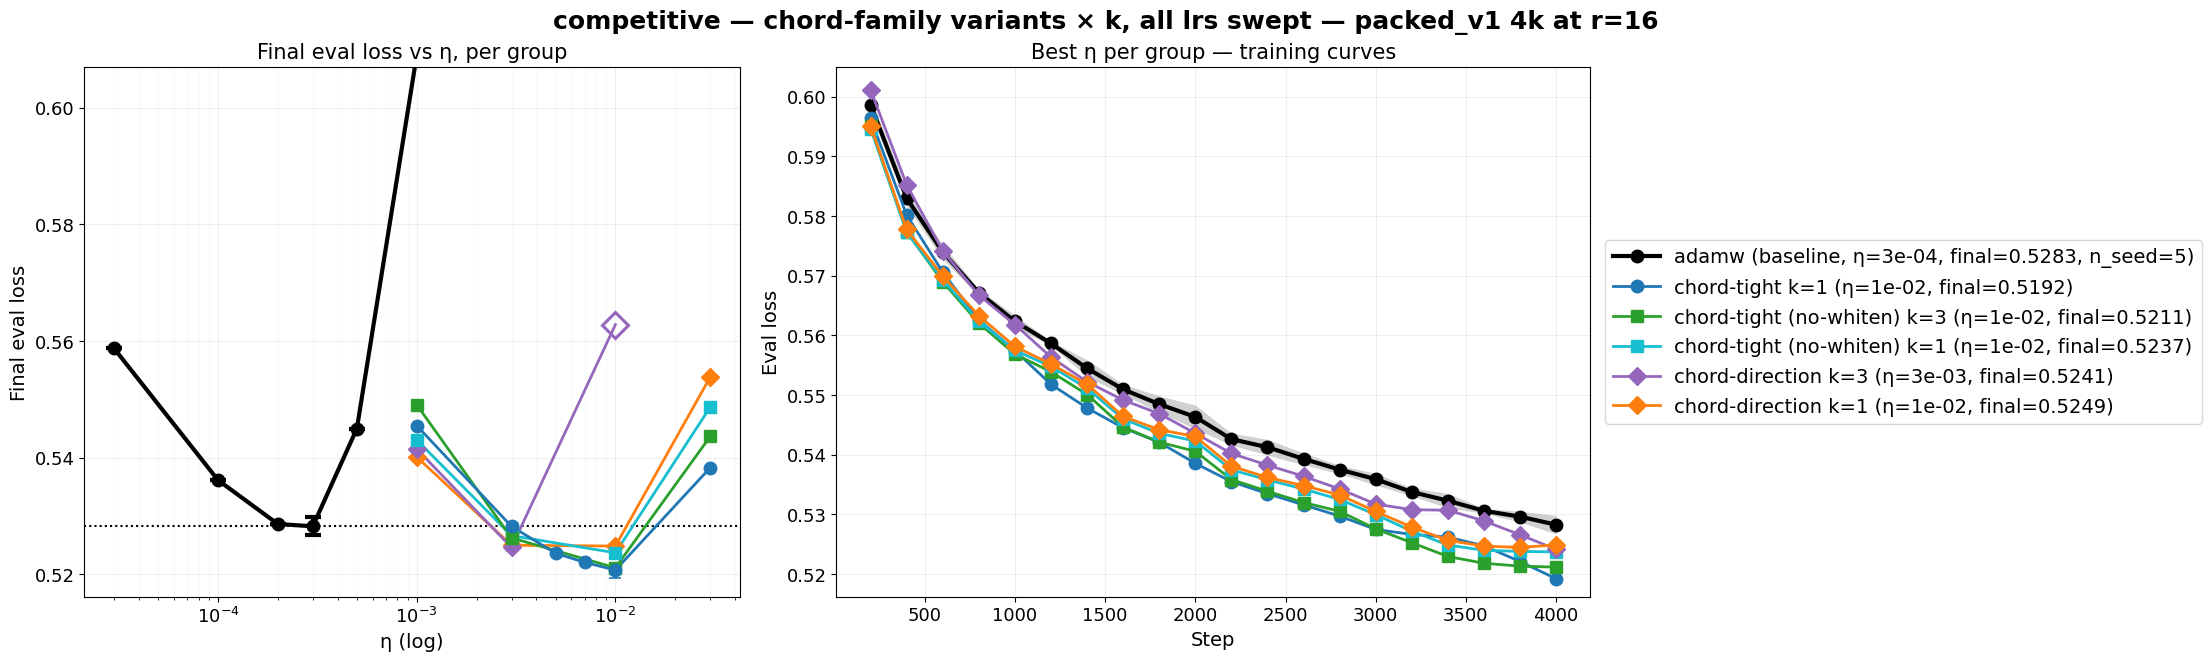

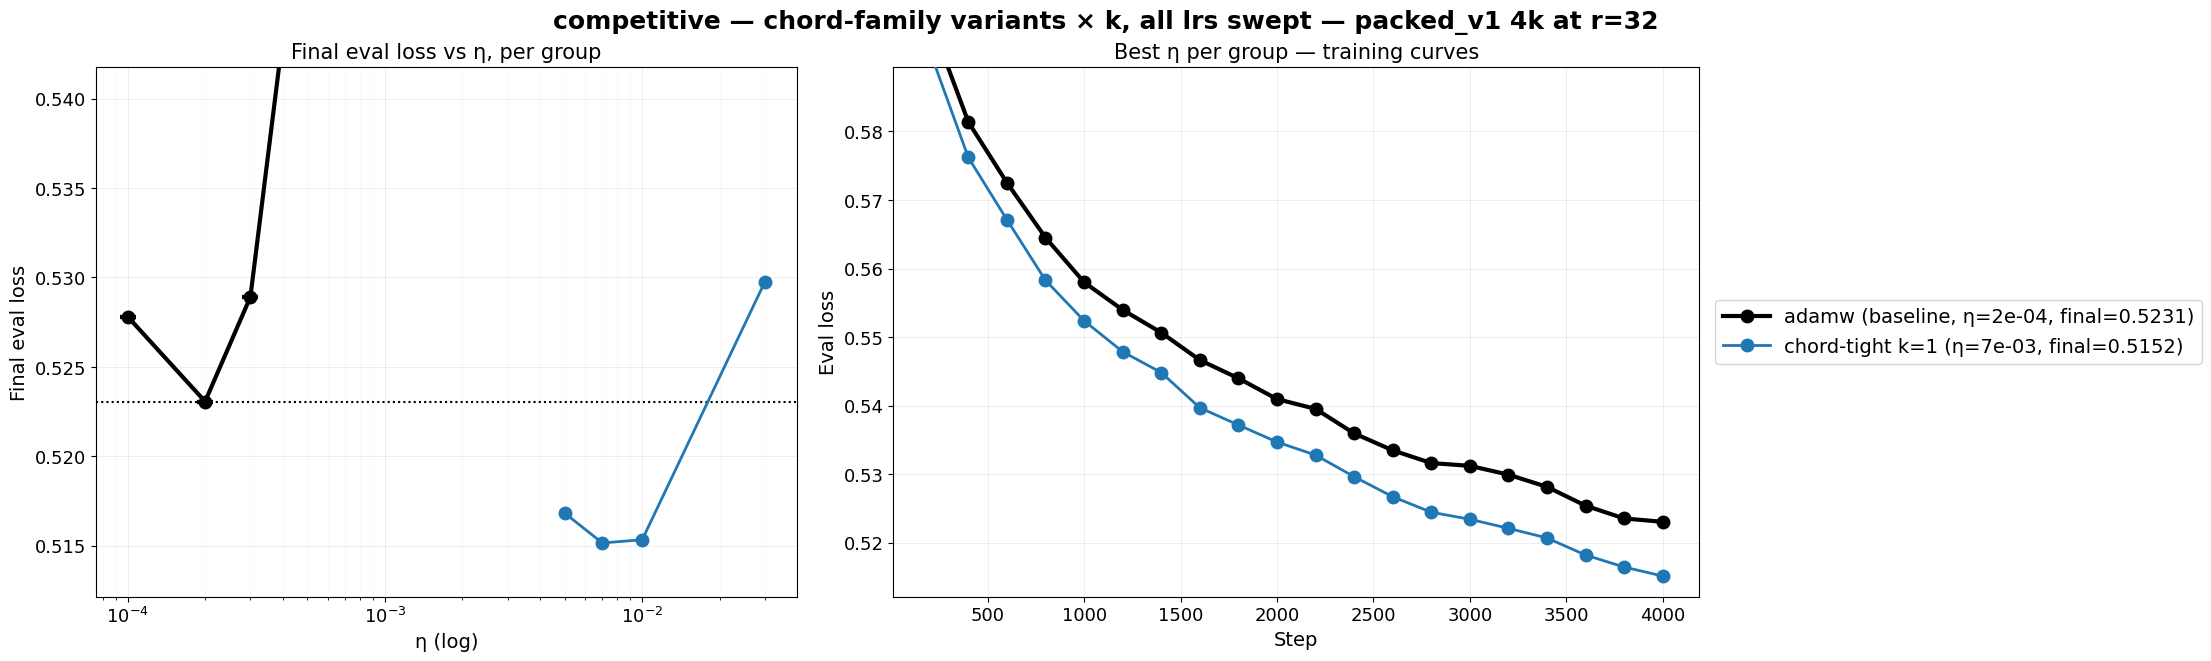

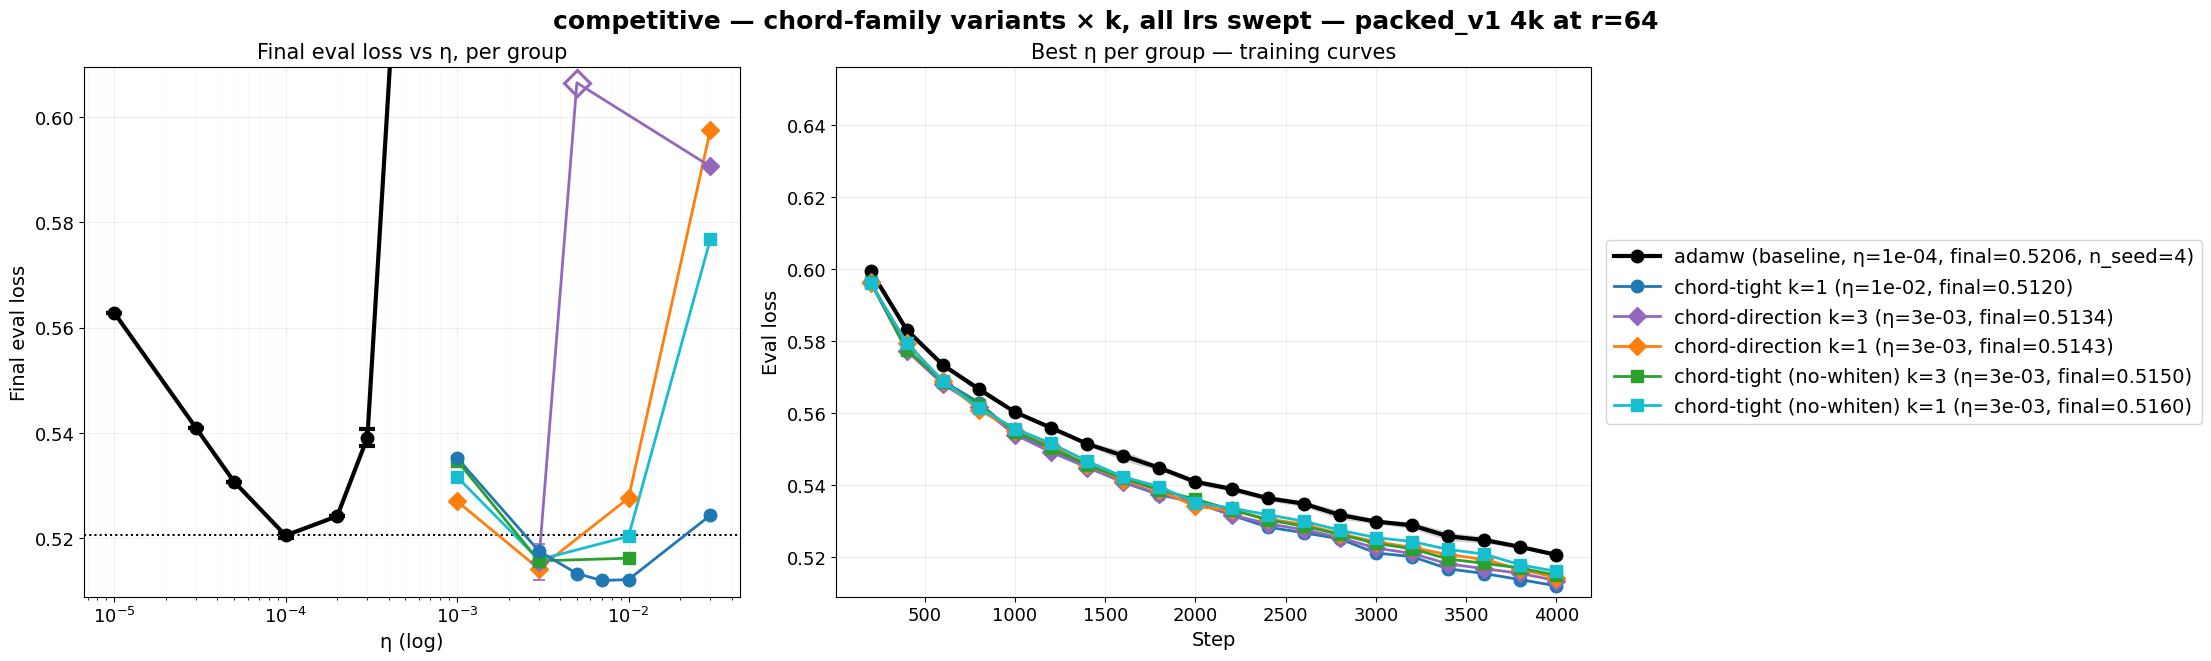

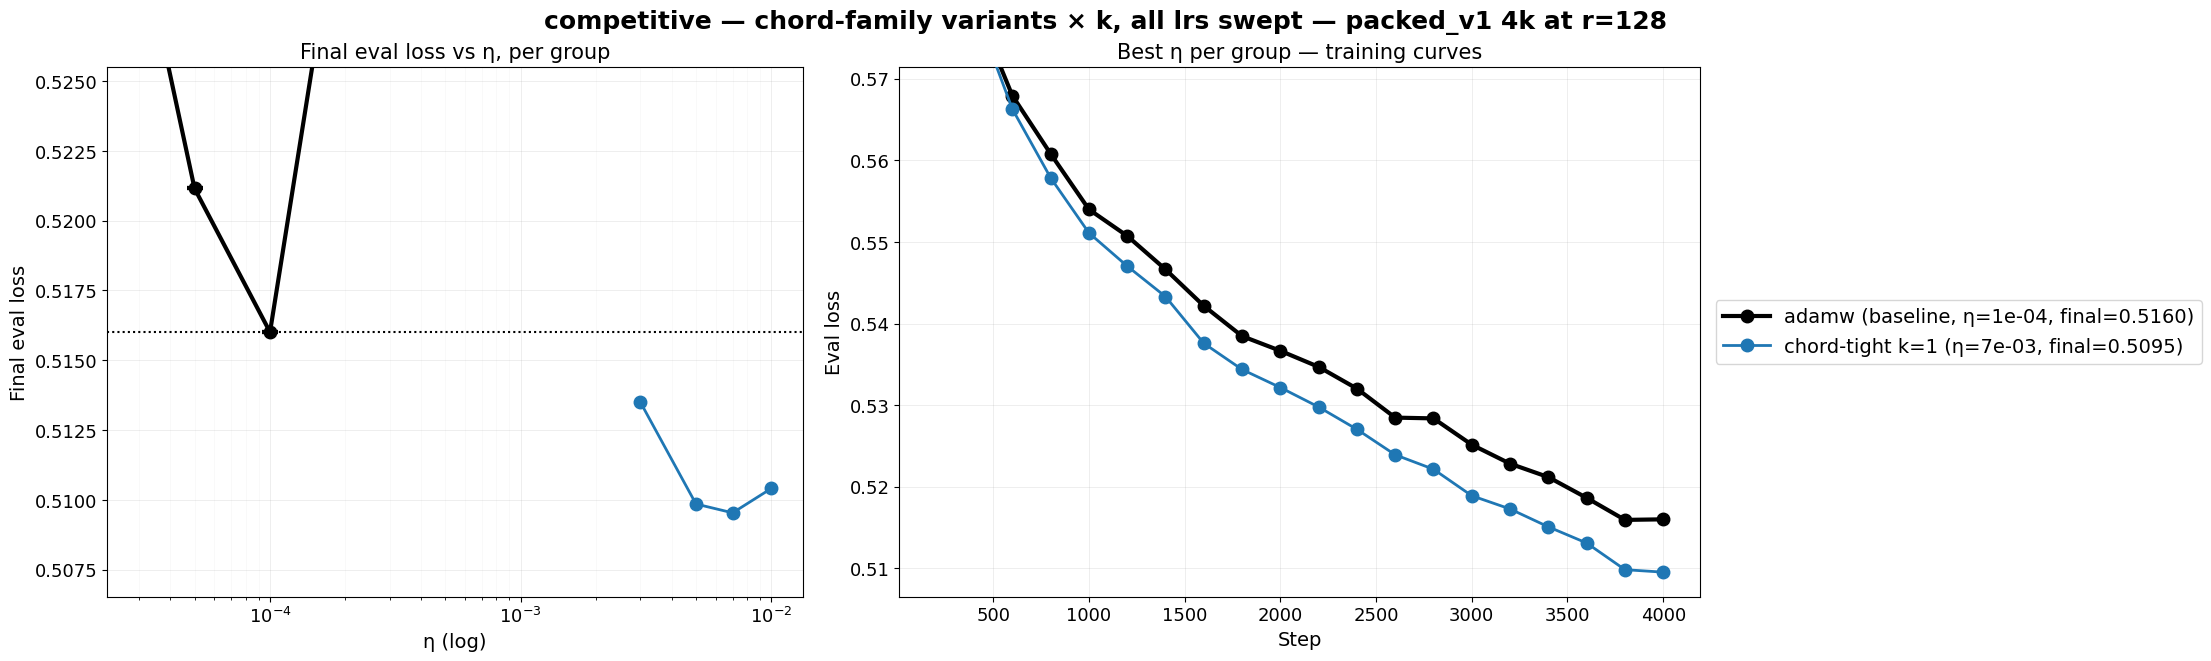

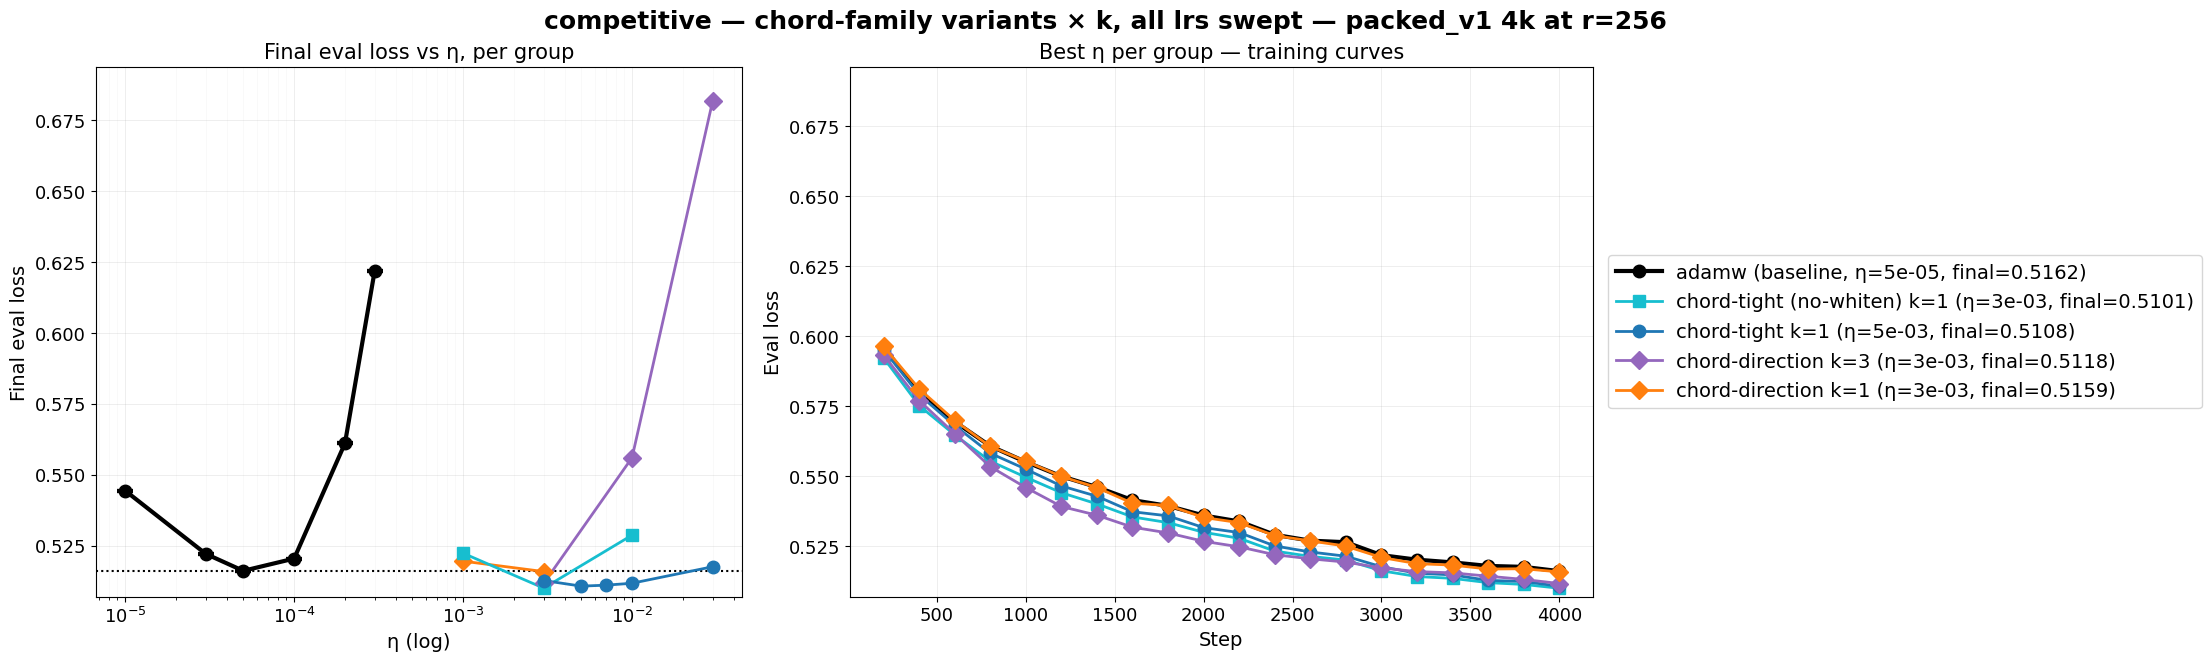

In [7]:
# Family split + variant exclusion.
#
# `filter_baseline(varying=(...))` drops runs that deviate from the modal
# value on any axis NOT listed (and not in `manifest.SERIES_AXIS_FIELDS`).
# Here we vary `optimizer` (variant slug) and `effective_picard_iters`
# (k=1 vs k=3). Anything off-default on init_b / precond_delta / damping /
# data_dir / compile / etc. is automatically excluded — those belong to the
# dedicated variant cells below (Init[AB], eps_rel) or to stale-commit
# legacy runs (different data_dir / compile=False).
from lora_playground.plot_utils import filter_baseline
import math

WHITEN   = 'adam-polar-product-lora-coupled-spectral-chord-tight'
NOWHITEN = 'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening'
DIRECT   = 'adam-polar-product-lora-coupled-spectral-chord-direction'
FROB     = 'adam-polar-product-lora-coupled'

# chord-tight (whiten) k=3 with default-abs damping is excluded — it's
# both less stable and underperforms the ε_rel-damped k=3 (see the
# isolated chord-tight cell + ε_rel sweep cell below). Keep k=1 only
# for the whitened variant in the competitive grid.
COMPETITIVE_VARIANT_K = {
    (WHITEN,   1),
    (NOWHITEN, 1), (NOWHITEN, 3),
    (DIRECT,   1), (DIRECT,   3),
}

def is_competitive(cfg):
    k = cfg.get('_derived', {}).get('effective_picard_iters')
    return (cfg['optimizer'], k) in COMPETITIVE_VARIANT_K

# Variant-clean baseline run set: default damping, default init_b, project-
# wide data/compile baseline. Both competitive and supplementary partitions
# are subsets of this.
clean_runs = filter_baseline(
    cand_runs,
    varying=('optimizer', 'effective_picard_iters'),
)
competitive_runs   = [r for r in clean_runs if is_competitive(r[0])]
supplementary_runs = [r for r in clean_runs if not is_competitive(r[0])]

def _cell_count(runs):
    return len({(c['optimizer'],
                 c.get('_derived', {}).get('effective_picard_iters'),
                 c['lora_r'], c['lr']) for c, _ in runs})

print(f'baseline-clean runs: {len(clean_runs)} (filtered out {len(cand_runs) - len(clean_runs)} variant/legacy runs)')
print(f'  competitive:   {len(competitive_runs)} across {_cell_count(competitive_runs)} cells')
print(f'  supplementary: {len(supplementary_runs)} across {_cell_count(supplementary_runs)} cells')

# Per-rank ylim is data-driven. Two different bounds:
#   LEFT panel (final-loss-vs-η): tight bound on final eval_loss + small
#     margin so converged-region differences stay visible.
#   RIGHT panel (trajectory): upper bound = max eval_loss past warmup
#     (step ≥ warmup_frac * max_step) — keeps full convergence visible
#     while cropping the very-early spike.
#
# **NaN-safe**: diverged runs (NaN-final at r=256 k=3 lr=1e-2, 3e-2) leak
# in via `competitive_runs`; `is not None` is True for `float('nan')`, so
# unfiltered max(...) returns NaN → set_ylim crashes. Use math.isfinite
# to drop both NaN and inf cleanly.
def _is_finite(v):
    return v is not None and isinstance(v, (int, float)) and math.isfinite(v)

def _auto_ylim_final(runs, rank, *, lower_pad=0.003, upper_pad=0.012):
    finals = [e[-1].get('eval_loss') for c, e in runs
              if c.get('lora_r') == rank and e
              and _is_finite(e[-1].get('eval_loss'))]
    if not finals:
        return (0.505, 0.620)
    return (min(finals) - lower_pad, max(finals) + upper_pad)

def _auto_ylim_traj(runs, rank, *, warmup_frac=0.2,
                    lower_pad=0.003, upper_pad=0.010):
    post_warmup, finals = [], []
    for c, e in runs:
        if c.get('lora_r') != rank or not e:
            continue
        max_step = max((ev.get('step') or 0) for ev in e) or 1
        cutoff = warmup_frac * max_step
        for ev in e:
            v = ev.get('eval_loss')
            if not _is_finite(v) or (ev.get('step') or 0) < cutoff:
                continue
            post_warmup.append(v)
        last = e[-1].get('eval_loss')
        if _is_finite(last):
            finals.append(last)
    if not post_warmup:
        return (0.505, 0.620)
    lo = (min(finals) if finals else min(post_warmup)) - lower_pad
    return (lo, max(post_warmup) + upper_pad)

NORMALIZE_X_TO_OPTIMUM = False  # False=raw eta on x-axis; True=eta/eta* aligned

def _render(runs, suptitle):
    out = standard_sweep_figure(
        runs,
        group_key_fn=group_key,
        color_map=color_map,
        reference_runs=ref_runs,
        suptitle=suptitle,
        same_value_axes=('lora_plus_multiplier',),
        marker_map=marker_map,
        figsize=(22, 6.5),
        x_tick_step=500,
        normalize_x_to_optimum=NORMALIZE_X_TO_OPTIMUM,
    )
    # Single-rank → tuple; multi-rank → list of tuples. Normalize.
    results = out if isinstance(out, list) else [out]
    for fig, axes, _n_keep, _n_drop in results:
        rank = None
        title = fig._suptitle.get_text() if fig._suptitle else ''
        for r_try in (256, 128, 64, 32, 16):
            if f'r={r_try}' in title or f'lora_r={r_try}' in title:
                rank = r_try
                break
        axes[0].set_ylim(*_auto_ylim_final(runs, rank))
        axes[1].set_ylim(*_auto_ylim_traj(runs, rank))
    return results

_render(competitive_runs,
        'competitive — chord-family variants × k, all lrs swept — packed_v1 4k')
plt.show()


## Isolated — chord-tight (whiten) k=1 vs k=3

Just the `adam-polar-product-lora-coupled-spectral-chord-tight` (whitened) variant at k=1 and k=3, dropping no-whiten / direction / frob to make the k comparison readable on its own.

chord-tight (whiten) runs: 75 across 48 cells (31 default-δ + 44 damped k=3)
  [auto] min_step inferred from cfg['max_steps']: 4000
  [auto] min_step inferred from cfg['max_steps']: 4000
  [auto] min_step inferred from cfg['max_steps']: 4000
  [auto] min_step inferred from cfg['max_steps']: 4000
  [auto] min_step inferred from cfg['max_steps']: 4000


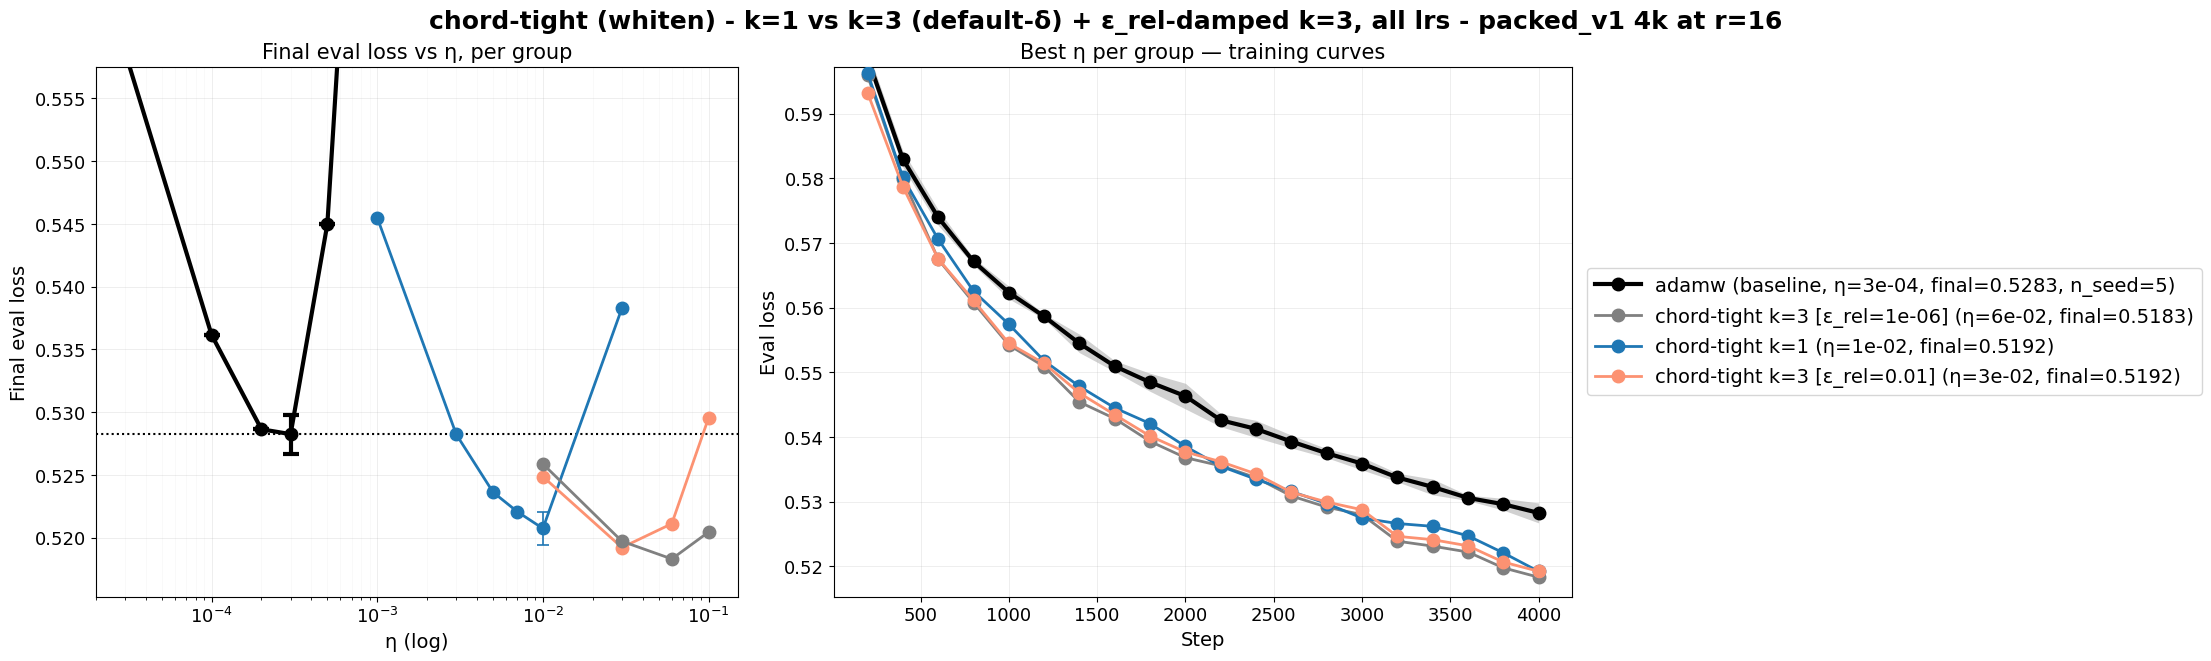

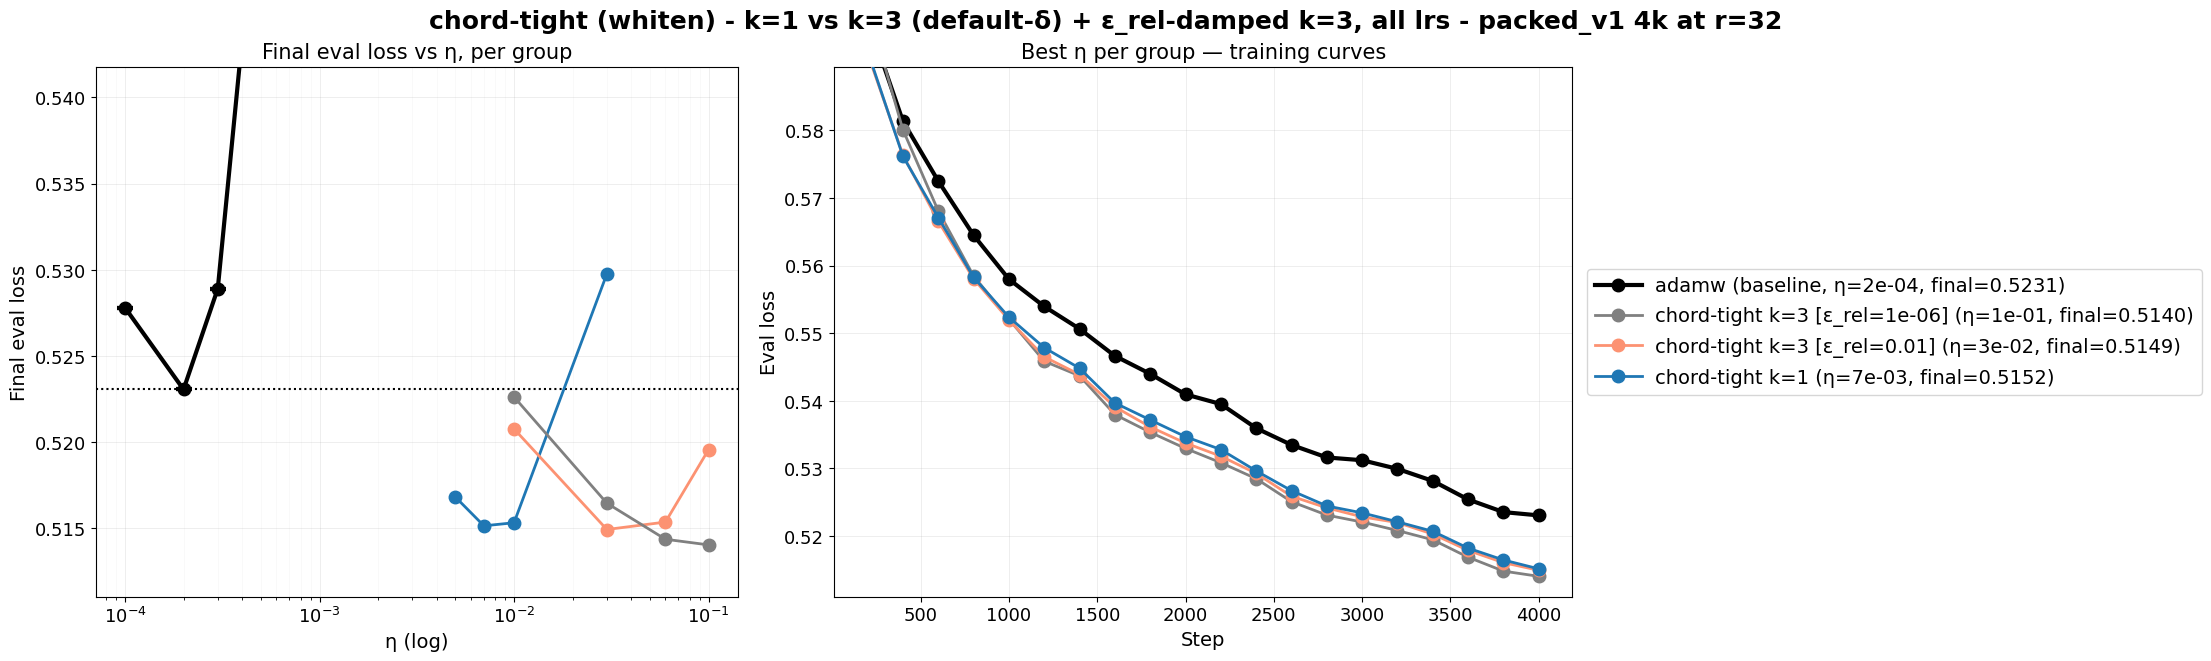

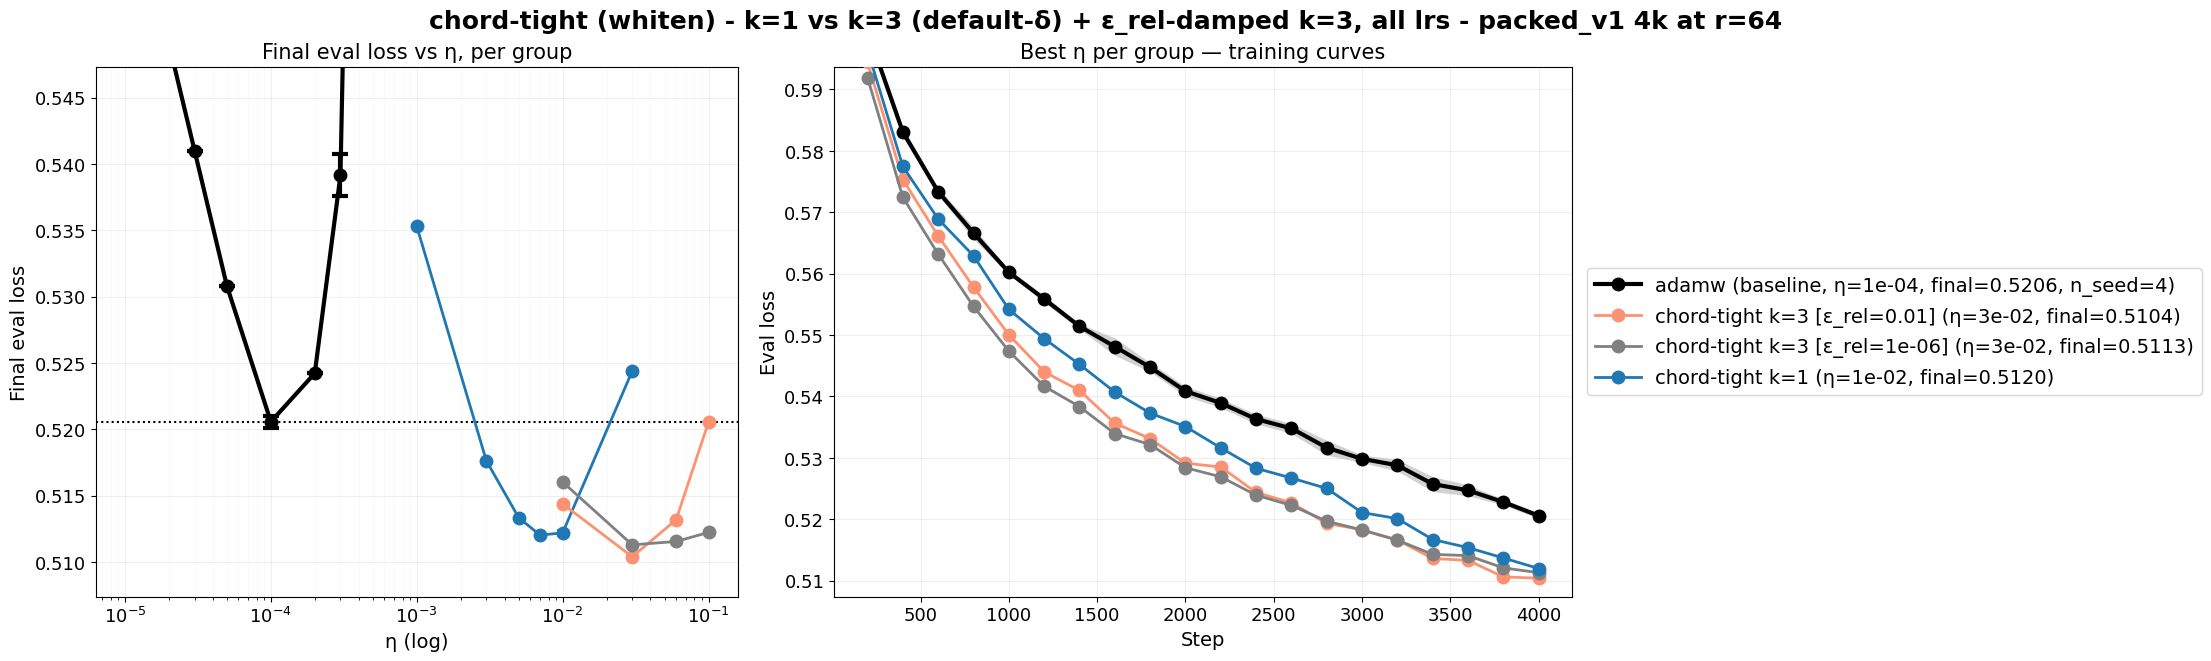

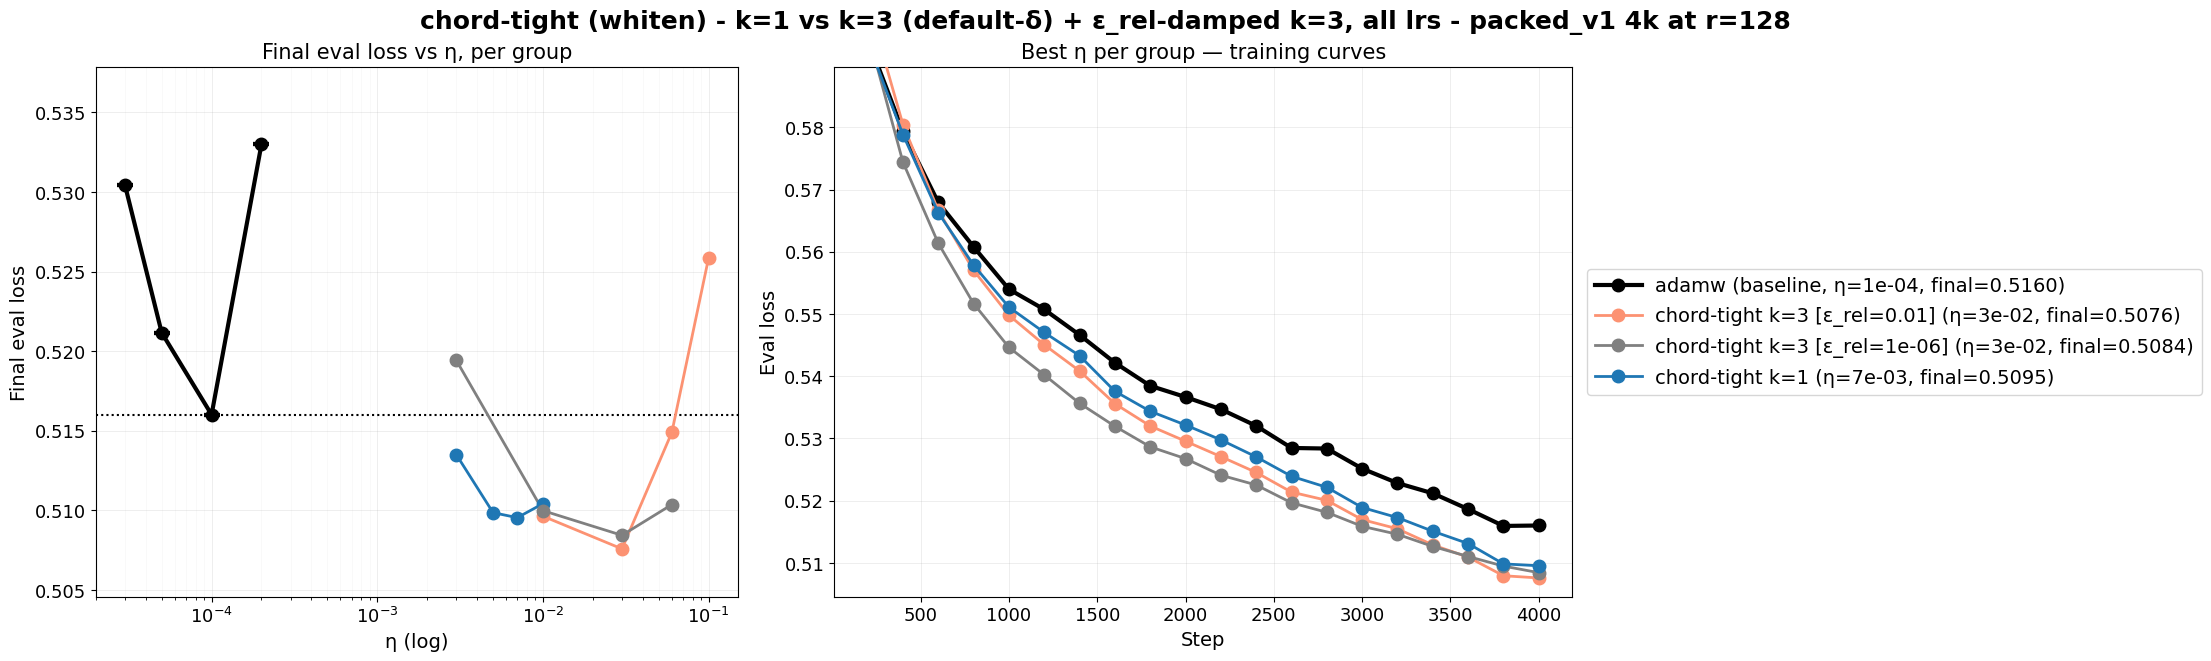

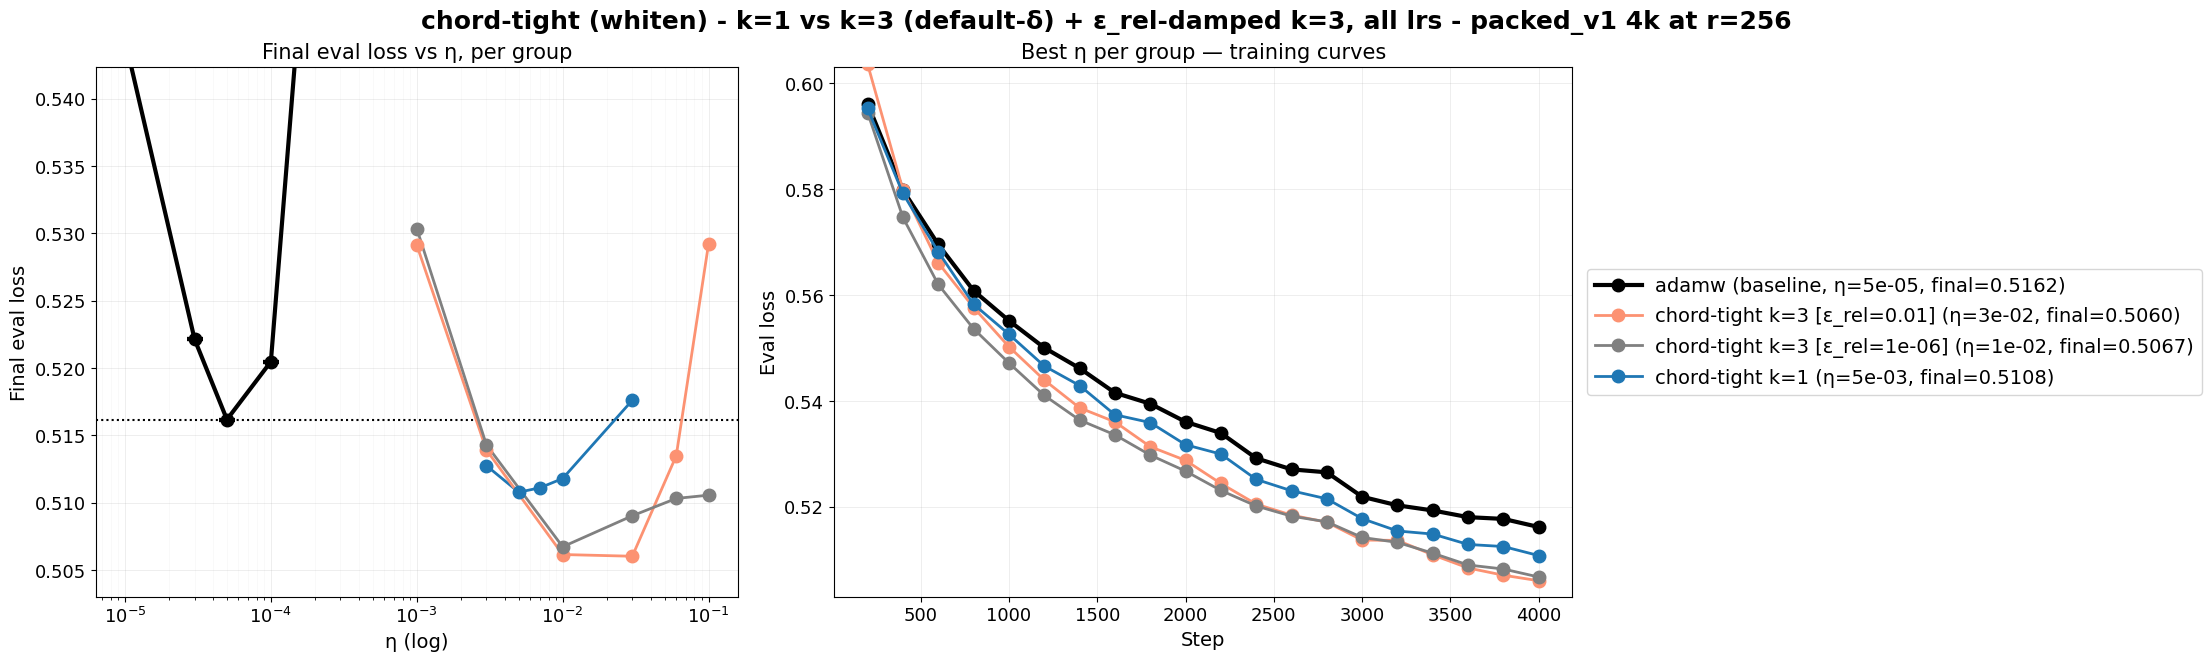

In [8]:
# chord-tight (whiten) only: k=1 (default-δ), k=3 (default-δ), and
# ε_rel-damped k=3 ONLY. (No damped k=1.)
from lora_playground.plot_utils import filter_variants

chord_tight_default = [
    (c, e) for c, e in competitive_runs
    if c['optimizer'] == WHITEN
]
chord_tight_damped_k3 = [
    (c, e) for c, e in filter_variants(
        cand_runs, on=('precond_delta_relative', 'precond_delta')
    )
    if c['optimizer'] == WHITEN
    and c.get('_derived', {}).get('effective_picard_iters') == 3
]
chord_tight_only = chord_tight_default + chord_tight_damped_k3
print(f'chord-tight (whiten) runs: {len(chord_tight_only)} across '
      f'{_cell_count(chord_tight_only)} cells '
      f'({len(chord_tight_default)} default-δ + {len(chord_tight_damped_k3)} damped k=3)')

# Distinct hues across the damping sweep — _damping_tag uses :g format,
# so ε_rel=1e-3 renders as 0.001 and 1e-4 as 0.0001.
color_map.setdefault('chord-tight k=3 [ε_rel=0.0001]', '#fee5d9')  # very light red
color_map.setdefault('chord-tight k=3 [ε_rel=0.001]',  '#fcbba1')  # light red
color_map.setdefault('chord-tight k=3 [ε_rel=0.01]',   '#fc9272')  # mid red
color_map.setdefault('chord-tight k=3 [ε_rel=0.1]',    '#de2d26')  # deep red
marker_map.setdefault('chord-tight k=3 [ε_rel=0.0001]', 'o')
marker_map.setdefault('chord-tight k=3 [ε_rel=0.001]',  'o')
marker_map.setdefault('chord-tight k=3 [ε_rel=0.01]',   'o')
marker_map.setdefault('chord-tight k=3 [ε_rel=0.1]',    'o')

_render(chord_tight_only,
        'chord-tight (whiten) - k=1 vs k=3 (default-δ) + ε_rel-damped k=3, '
        'all lrs - packed_v1 4k')
plt.show()


## Init[A] vs Init[AB] comparison

Focused view: chord-tight whiten and no-whiten k=1 at r=256, comparing default Init[A] (B=0 at init) vs Init[AB] (B initialized with PiSSA-style symmetric init).

Init[AB]'s lr-optimum lives below Init[A]'s — Init[A] best is lr=5e-3 at r=256; Init[AB] best is around lr=3e-3.

envelope (r=256, k=1, whiten/no-whiten): 17 runs
  Init[A] baseline: 8,  Init[AB] variant: 9
    chord-tight k=1 [Init[AB]]: 5 runs
    chord-tight k=1: 5 runs
    chord-tight (no-whiten) k=1 [Init[AB]]: 4 runs
    chord-tight (no-whiten) k=1: 3 runs
  [auto] min_step inferred from cfg['max_steps']: 4000


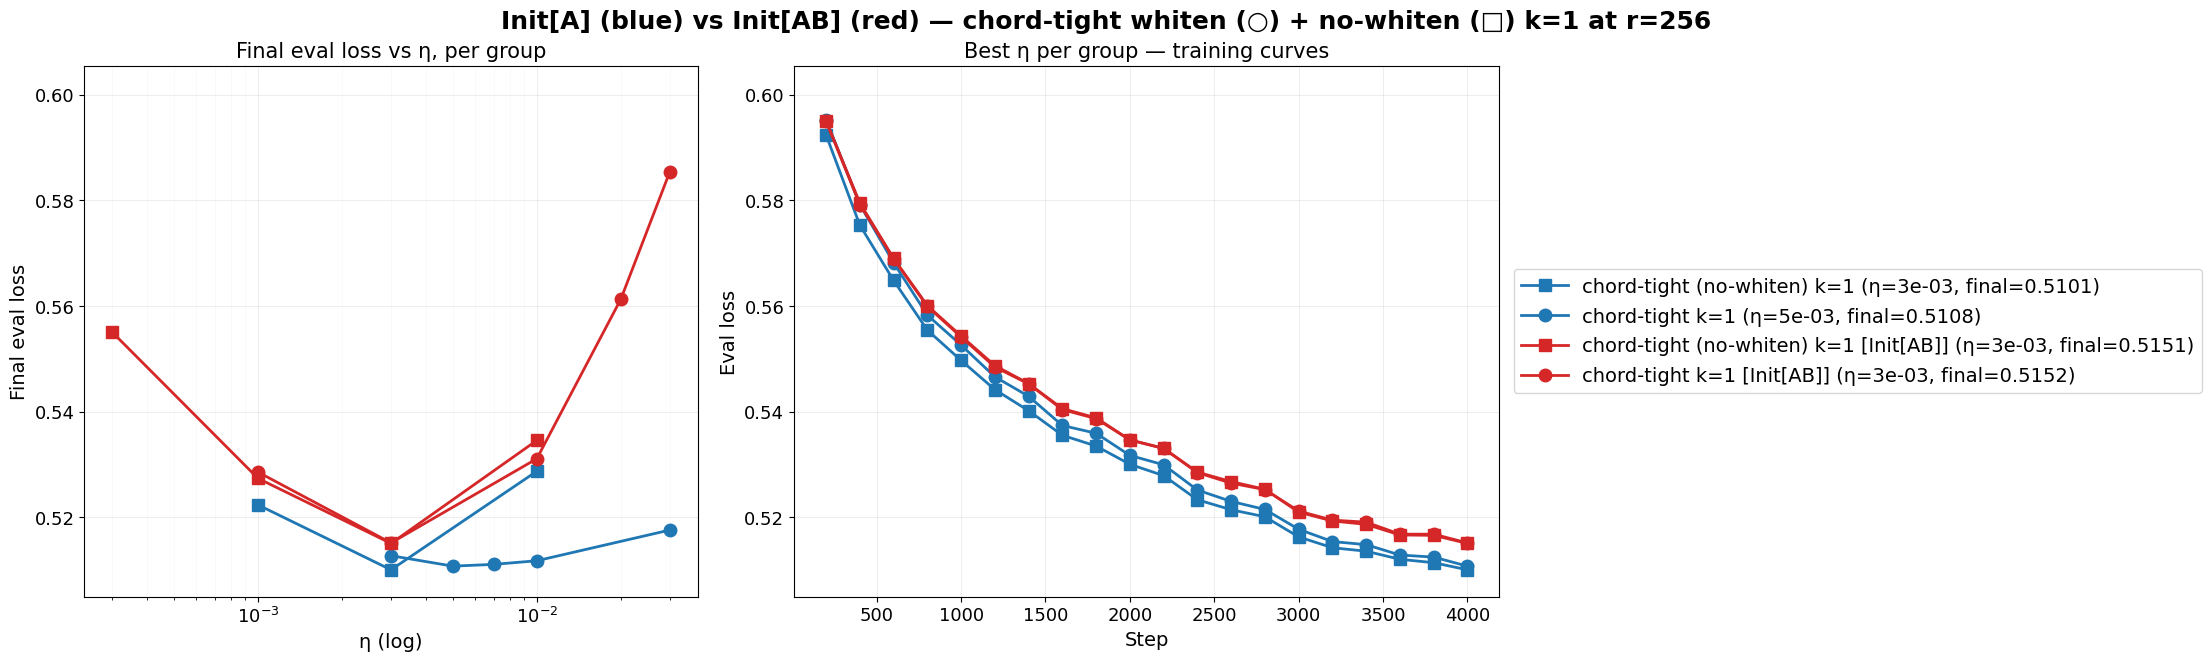

In [9]:
# Init[A] vs Init[AB] focused comparison.
# Restrict to the comparison ENVELOPE first (r=256, k=1, chord-tight
# whiten + no-whiten), THEN split into baseline (Init[A]) and variant
# (Init[AB]). filter_baseline computes modal within its varying-tuple
# group, so if the envelope isn't applied first, k=3 runs (the global
# modal k for these optimizers) would skew the per-optimizer modal
# and exclude legit k=1 baseline runs.
#
# Color encoding (local override, differs from the global leaderboard):
#   hue    = init scheme (Init[A] vs Init[AB] — the comparison axis)
#   marker = variant (whiten vs no-whiten)
from lora_playground.plot_utils import filter_variants, filter_baseline

def in_compare_envelope(cfg):
    if cfg.get('lora_r') != 256: return False
    if cfg.get('_derived', {}).get('effective_picard_iters') != 1: return False
    return cfg['optimizer'] in (WHITEN, NOWHITEN)

envelope_runs = [r for r in cand_runs if in_compare_envelope(r[0])]
initAB_variant = filter_variants(envelope_runs, on=('lora_init_b',))
initA_baseline = filter_baseline(envelope_runs, varying=('optimizer',))
initAB_runs = initAB_variant + initA_baseline

print(f'envelope (r=256, k=1, whiten/no-whiten): {len(envelope_runs)} runs')
print(f'  Init[A] baseline: {len(initA_baseline)},  Init[AB] variant: {len(initAB_variant)}')
from collections import Counter
for lbl, n in Counter(group_key(c) for c, _ in initAB_runs).most_common():
    print(f'    {lbl}: {n} runs')

INITAB_COLOR = {
    'chord-tight k=1':                          '#1f77b4',  # blue - Init[A]
    'chord-tight (no-whiten) k=1':              '#1f77b4',  # blue - Init[A]
    'chord-tight k=1 [Init[AB]]':               '#d62728',  # red  - Init[AB]
    'chord-tight (no-whiten) k=1 [Init[AB]]':   '#d62728',  # red  - Init[AB]
}
INITAB_MARKER = {
    'chord-tight k=1':                          'o',  # circle - whiten
    'chord-tight k=1 [Init[AB]]':               'o',
    'chord-tight (no-whiten) k=1':              's',  # square - no-whiten
    'chord-tight (no-whiten) k=1 [Init[AB]]':   's',
}

fig, axes, _n_keep, _n_drop = standard_sweep_figure(
    initAB_runs,
    group_key_fn=group_key,
    color_map=INITAB_COLOR,
    reference_runs=None,
    suptitle='Init[A] (blue) vs Init[AB] (red) \u2014 chord-tight whiten (\u25cb) + no-whiten (\u25a1) k=1 at r=256',
    same_value_axes=('lora_plus_multiplier',),
    marker_map=INITAB_MARKER,
    figsize=(22, 6.5),
    x_tick_step=500,
    normalize_x_to_optimum=NORMALIZE_X_TO_OPTIMUM,
)
# Auto-tighten right-panel ylim to converged range: upper bound is
# max(final eval_loss) across rendered series + small margin, so
# late-training differences between Init[A] and Init[AB] stay visible
# instead of being compressed by the early-training spike.
finals = [e[-1].get('eval_loss') for _, e in initAB_runs
          if e and e[-1].get('eval_loss') is not None]
top = max(finals) + 0.02 if finals else 0.610
axes[0].set_ylim(0.505, top)
axes[1].set_ylim(0.505, top)
plt.show()


## ε_rel sweep — does damping help at r=256 chord-tight whiten?

Background: at r=256 chord-tight whiten Init[A], `SB^{-1/2}` is ill-conditioned because B is rank-deficient early in training. `cos_A` shows the per-step update is rotated 60° from the plain-Adam direction. ε_rel-relative damping (`δ_eff = ε_rel · σ_max(SB)`) reduces the rotation.

**Question:** does ε_rel translate the alignment fix into a final-loss win, or is the SB^{-1/2} rotation a non-load-bearing diagnostic?

Sweep: lr × ε_rel grid at r=256, k=1, Init[A]. Compared against the default-damping (`δ=1e-6` absolute) lr-sweep as the no-ε_rel baseline.

  [loader] excluded 160 run(s): 11 for 'Superseded by later chord-tight runs at the same cfg; +0.01 above seed cluster. See log_00 entry.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_01.out, r64_chord_postfix_validation_4k_blackwell/log_02.out, r64_chord_postfix_validation_4k_blackwell/log_03.out, +8 more); 1 for 'Superseded by later chord-tight runs at the same cfg; runs systematically +0.01 above seed cluster from descendants of ef6b3bc. Legacy registry entry blanket-excluded commit 91122ce; we narrow to the affected group since the bug surface was specific to this validation sweep.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_00.out); 7 for 'buggy ε_rel (contam rerun cleanup, pre-λ_max-fix)' (e.g. eps_rel_lr_tuned_4k_blackwell/log_00.out, eps_rel_lr_tuned_4k_blackwell/log_01.out, eps_rel_lr_tuned_4k_blackwell/log_02.out, +4 more); 8 for 'buggy ε_rel (precond_delta_relative fix applied but pre-λ_max-fix (9677abe))' (e.g. chord_tight_k3_eps_rel_1e-2_r16r64_lr_sweep_4k_

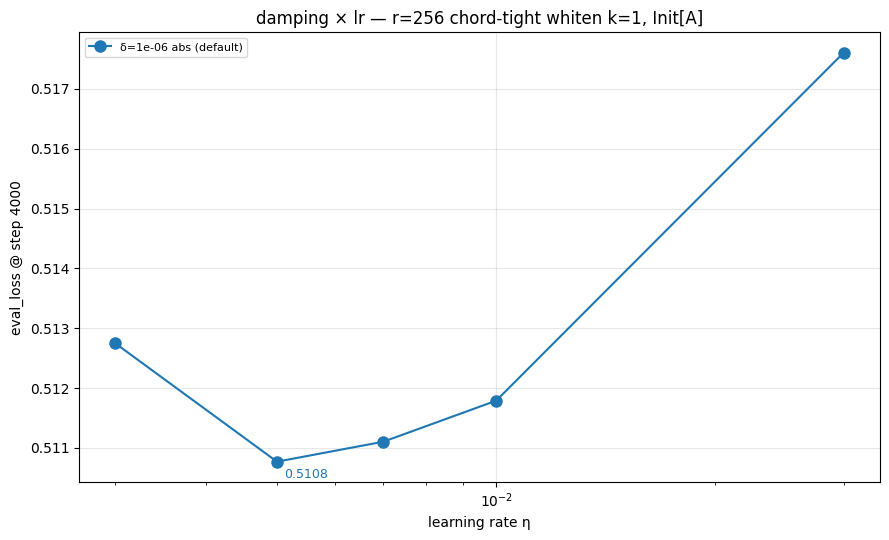

In [10]:
# ε_rel sweep: final loss vs lr, one series per ε_rel value.
# Filters: r=256, chord-tight whiten k=1, Init[A] (lora_init_b=zero), max_steps=4000.
import re
import numpy as np

def _parse_eps(cfg):
    """Read (precond_delta, precond_delta_relative_intended) from cfg.
    Reads cfg fields directly (populated by the loader's generic CLI
    backfill); falls back to the raw command string only if those fields
    are absent."""
    pd = cfg.get('precond_delta')
    if pd is None:
        m_pd = re.search(r'--precond_delta\s+(\S+)', cfg.get('command', ''))
        pd = float(m_pd.group(1)) if m_pd else 1e-6
    pd = float(pd)
    pdr = bool(cfg.get('precond_delta_relative')) or (
        '--precond_delta_relative' in cfg.get('command', ''))
    return pd, pdr


def _eps_label_for_cfg(cfg):
    pd, pdr = _parse_eps(cfg)
    if not pdr:
        return f'δ={pd:.0e} abs (default)'
    return f'ε_rel={pd:g}'


def is_eps_compare_cell(cfg):
    if cfg.get('lora_r') != 256: return False
    if cfg.get('optimizer') != WHITEN: return False
    if cfg.get('_derived', {}).get('effective_picard_iters') != 1: return False
    if (cfg.get('lora_init_b') or 'zero') != 'zero': return False
    if cfg.get('max_steps') != 4000: return False
    return True


eps_runs_all = load_runs(
    where={'optimizer': WHITEN, 'lora_r': 256,
           'data_pipeline_version': 'packed_v1', 'max_steps': 4000},
    logs_root='../logs', warn_cross_commit=False,
)
eps_runs = [(c, e) for c, e in eps_runs_all if is_eps_compare_cell(c)]

rows = []
seen = set()
for cfg, evs in eps_runs:
    if not evs or evs[-1].get('step') != 4000: continue
    pd, pdr = _parse_eps(cfg)
    lbl = _eps_label_for_cfg(cfg)
    lr = float(cfg['lr'])
    key = (round(lr, 6), lbl)
    if key in seen: continue
    seen.add(key)
    rows.append({'lr': lr, 'eps': lbl, 'pd': pd, 'pdr': pdr,
                 'final_loss': evs[-1]['eval_loss']})

rows.sort(key=lambda r: (r['eps'], r['lr']))
print(f"{'label':32s} {'lr':>10s}   final_loss")
for r in rows:
    print(f"  {r['eps']:30s} {r['lr']:>10.0e}   {r['final_loss']:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
eps_groups = sorted({r['eps'] for r in rows})
eps_colors = {
    'δ=1e-06 abs (default)':       '#1f77b4',
    'ε_rel=0.01':                  '#2ca02c',
    'ε_rel=0.1':                   '#d62728',
}
for lbl in eps_groups:
    pts = sorted([r for r in rows if r['eps'] == lbl], key=lambda r: r['lr'])
    if not pts: continue
    lrs = [p['lr'] for p in pts]
    losses = [p['final_loss'] for p in pts]
    color = eps_colors.get(lbl, '#666666')
    ax.plot(lrs, losses, 'o-', label=lbl, color=color, markersize=8, linewidth=1.5)
    i_best = int(np.argmin(losses))
    ax.annotate(f'{losses[i_best]:.4f}',
                xy=(lrs[i_best], losses[i_best]),
                xytext=(5, -12), textcoords='offset points',
                fontsize=9, color=color)

ax.set_xscale('log')
ax.set_xlabel('learning rate η')
ax.set_ylabel('eval_loss @ step 4000')
ax.set_title('damping × lr — r=256 chord-tight whiten k=1, Init[A]')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


### Supplementary — frob parent

`adam-polar-product-lora-coupled` (frob / AdaMuon parent, no chord-tight ρ). Different family from the chord variants — context only.


  [auto] min_step inferred from cfg['max_steps']: 4000
  [auto] min_step inferred from cfg['max_steps']: 4000
  [filtered diverged] chord-tight k=3 η=1e-02  max=inf final=nan
  [filtered diverged] chord-tight k=3 η=3e-02  max=inf final=nan
  [auto] min_step inferred from cfg['max_steps']: 4000


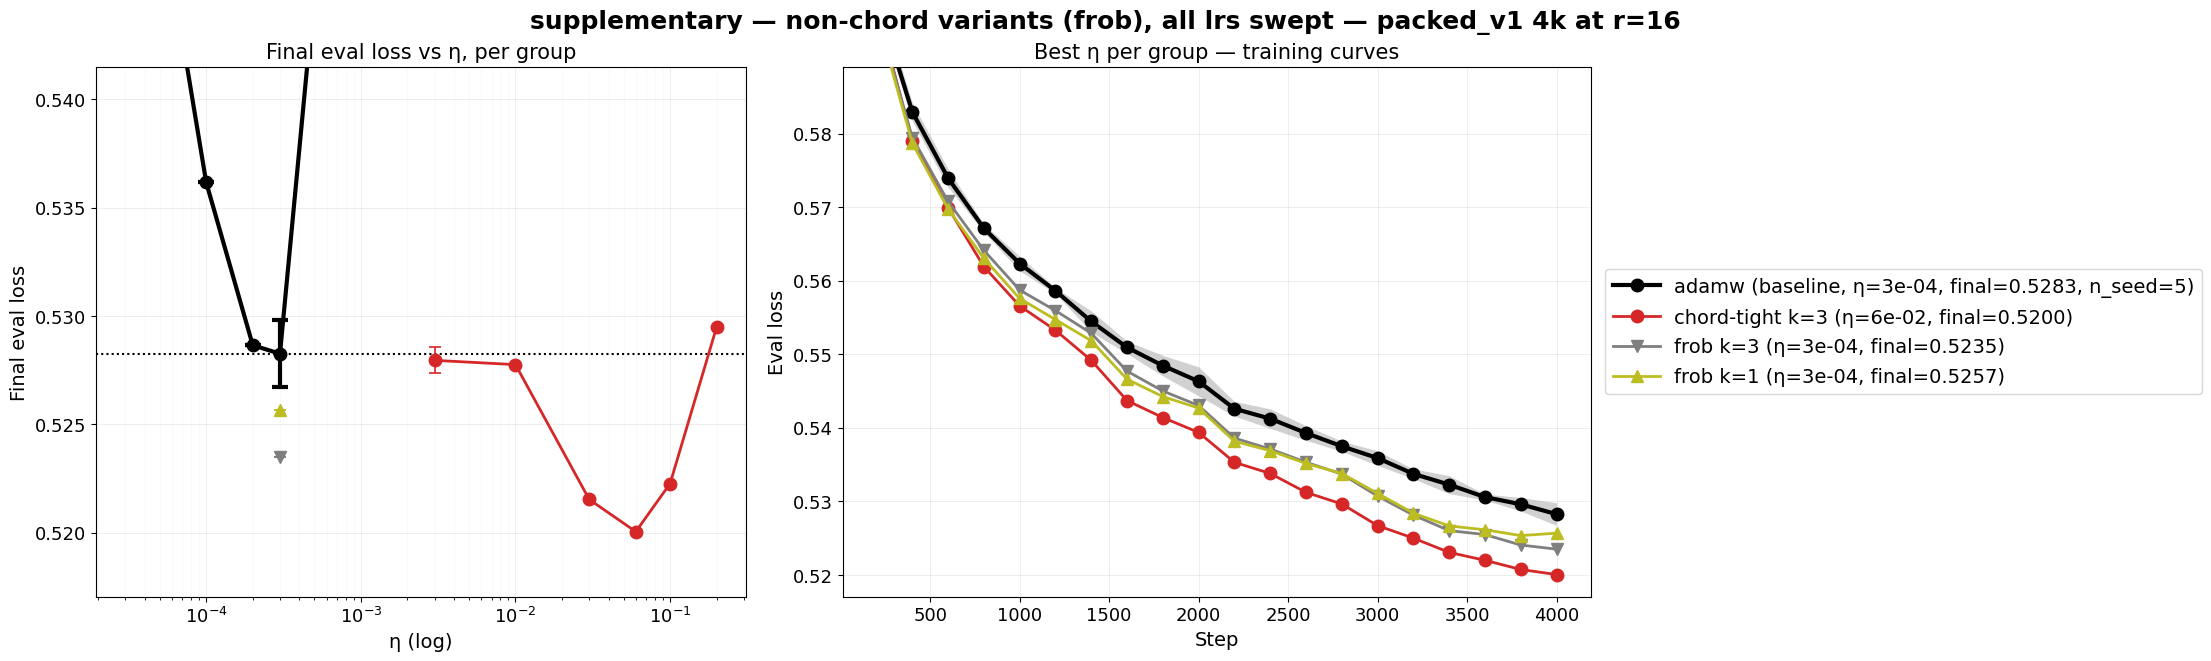

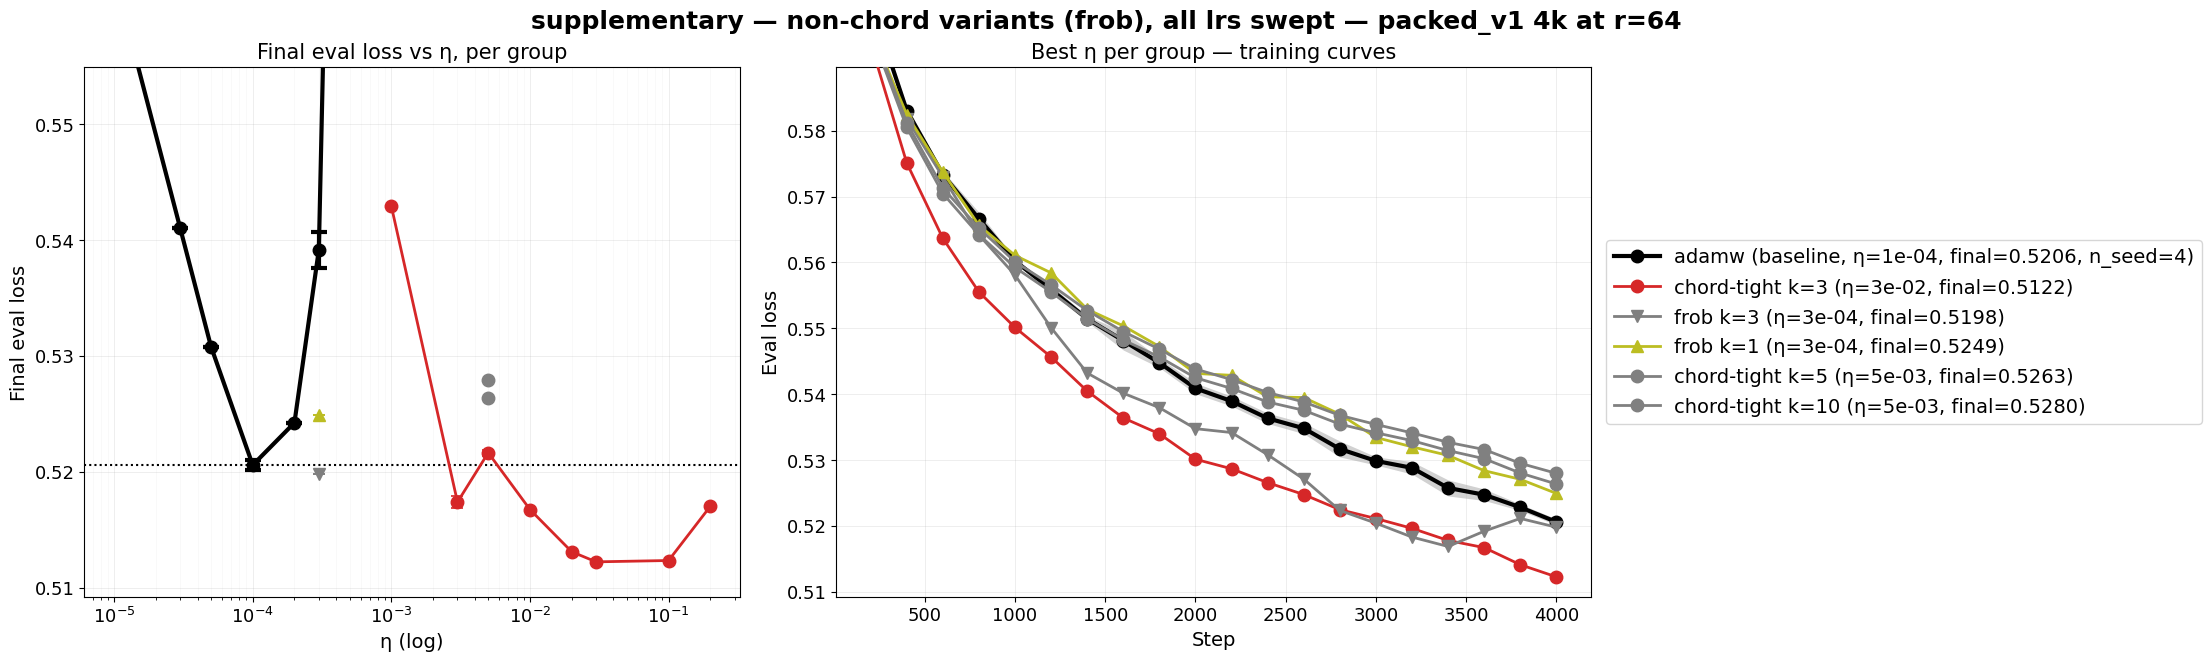

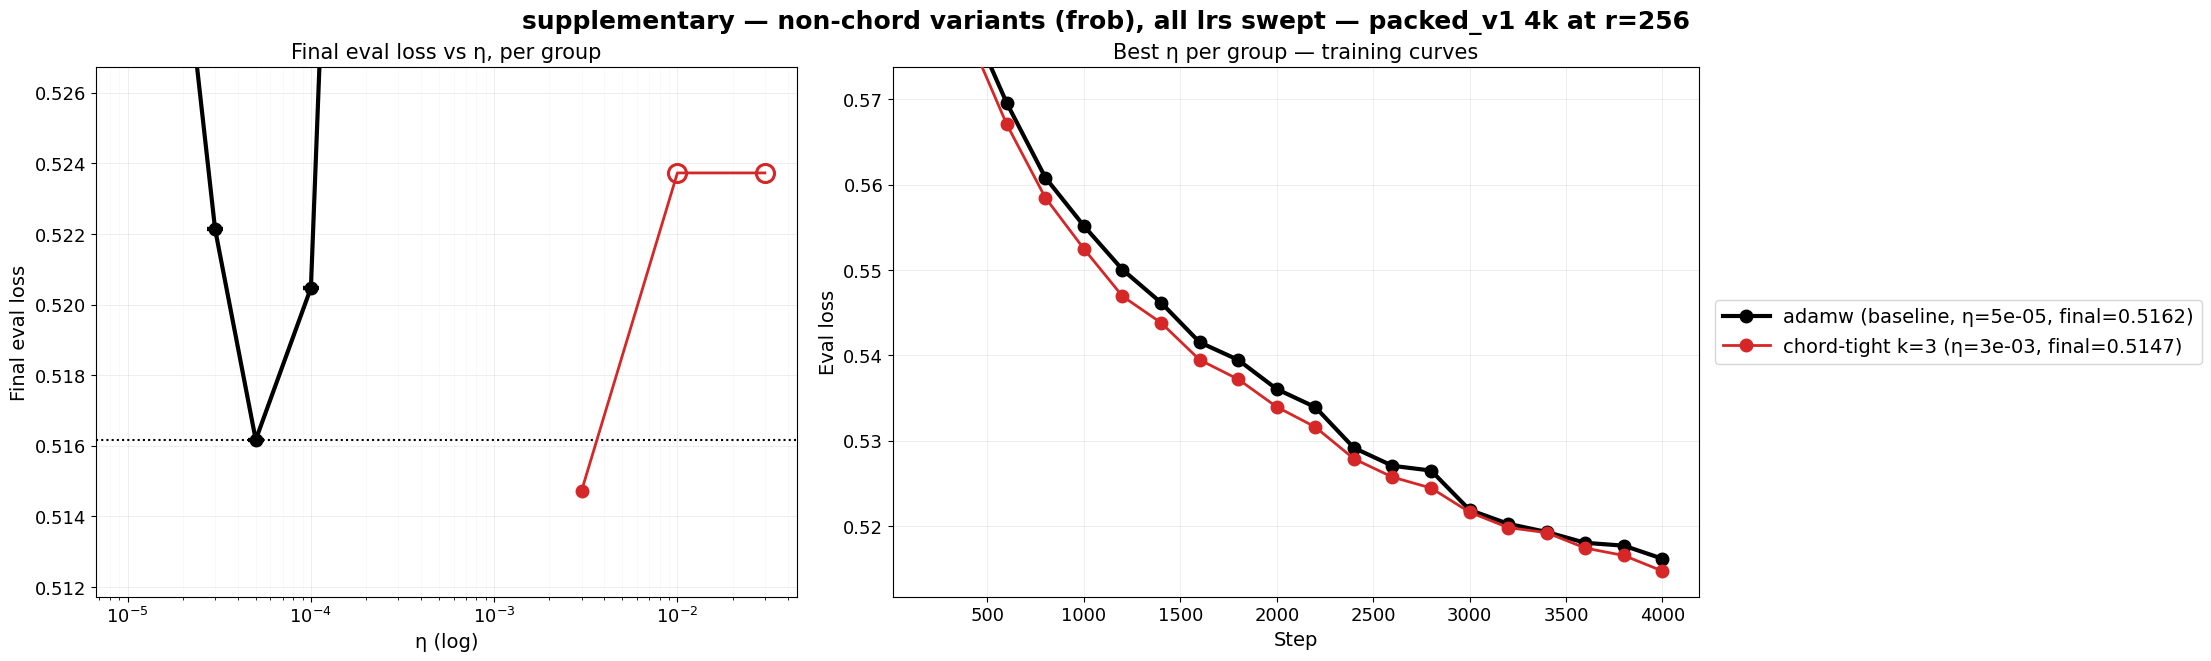

In [11]:
_render(supplementary_runs,
        'supplementary — non-chord variants (frob), all lrs swept — packed_v1 4k')
plt.show()


## §10-clean Algorithm 2′ + §8 no-ρ ablation — vs legacy chord-tight at r=64

Two new variants land here once the pending sweeps finish:

- **`adam-polar-product-lora-coupled-spectral-chord-tight-clean`** (k=3): Algorithm 2′ exactly as `docs/notes/polar_product/algorithm_tight_chord.md` §10 specifies — pre-rescale `u_A ← u_A/σ_max(X_A)`, linear `ρ = η/s`, `1/η` cross-coupling, Picard-iter-keyed warm-start at site C. Doc-faithful implementation; differs from legacy `chord-tight` at every k≥1 by the ρ-formula (~1.1%) and at k≥2 by the cross-coupling coefficient + warm-start.
- **`adam-polar-product-lora-coupled-spectral-chord-tight-no-rho`** (k=1): §8 ablation — drop the ρ-routed magnitude rescale entirely (no pre-rescale, no σ_max(A,B), no σ_max(geo) division). `dA = -η · S_B^(-1/2) polar(S_B^(-1/2) u_A)` directly. Tests whether the per-factor operator-norm cap (ρ-routing) buys anything over applying η as a raw scalar.

Baseline overlay: legacy `adam-polar-product-lora-coupled-spectral-chord-tight` r=64 single-seed lr-sweep from on-disk `chord_tight_diag_4k_r16r64_blackwell` + `chord_multiseed_lr3e3_k3_4k_r16r64_blackwell` seed=0.

σ_AdamW(packed_v1, r=64, 4k) = **0.0017** (from notebook intro). Δ-quotes below are in σ-units against this anchor. "Within 1σ" reserved for |Δ| < 0.0017.


In [ ]:
# Load the three variants at r=64, packed_v1, 4k horizon.
NEW_VARIANTS = [
    'adam-polar-product-lora-coupled-spectral-chord-tight-clean',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-rho',
]
LEGACY_TIGHT = 'adam-polar-product-lora-coupled-spectral-chord-tight'

new_runs = load_runs(
    where={'optimizer': NEW_VARIANTS, 'data_pipeline_version': 'packed_v1',
           'max_steps': 4000, 'lora_r': 64, 'seed': 0},
    logs_root='../logs', warn_cross_commit=False,
)
legacy_runs = load_runs(
    where={'optimizer': LEGACY_TIGHT, 'data_pipeline_version': 'packed_v1',
           'max_steps': 4000, 'lora_r': 64, 'seed': 0},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'new variants (clean + no_rho): {len(new_runs)} runs')
print(f'legacy chord-tight r=64 seed=0: {len(legacy_runs)} runs')

# Build leaderboard: (optimizer, k, lr) -> final eval_loss.
import pandas as pd
rows = []
for cfg, evs in new_runs + legacy_runs:
    if not evs:
        continue
    final = evs[-1]
    if final.get('step') != 4000 or final.get('eval_loss') is None:
        continue
    k = cfg.get('_derived', {}).get('effective_picard_iters')
    rows.append({
        'optimizer': cfg['optimizer'].replace('adam-polar-product-lora-coupled-spectral-', ''),
        'k': k,
        'lr': cfg['lr'],
        'eval_loss_4k': final['eval_loss'],
    })
df = pd.DataFrame(rows).sort_values(['optimizer', 'k', 'lr']).reset_index(drop=True)
print(df.to_string(index=False))

# Per-(optimizer, k) best-lr summary with σ-Δ against legacy chord-tight best.
SIGMA_ADAMW_R64 = 0.0017
print()
print('=' * 80)
print(f"Best-lr per (optimizer, k) — σ_AdamW(r=64) = {SIGMA_ADAMW_R64}")
print('=' * 80)
best = df.loc[df.groupby(['optimizer', 'k'])['eval_loss_4k'].idxmin()].reset_index(drop=True)
if (best['optimizer'] == 'chord-tight').any():
    ref_legacy = best.loc[best['optimizer'] == 'chord-tight', 'eval_loss_4k'].iloc[0]
else:
    ref_legacy = None
    print('(no legacy chord-tight r=64 seed=0 best-lr found — Δ vs legacy unavailable)')
for _, row in best.iterrows():
    delta_sigma = ((row['eval_loss_4k'] - ref_legacy) / SIGMA_ADAMW_R64) if ref_legacy is not None else float('nan')
    print(f"  {row['optimizer']:30s} k={row['k']} lr={row['lr']:.0e} "
          f"eval={row['eval_loss_4k']:.4f} Δσ_vs_legacy={delta_sigma:+.2f}")


In [ ]:
# Two-panel figure:
#   Left:  eval_loss at step 4000 vs lr (per-variant curves; lower is better)
#   Right: trajectory eval_loss vs step at each variant's best lr
import numpy as np
import matplotlib.pyplot as plt

VARIANT_COLOR = {
    'chord-tight-clean':  '#5a2d20',
    'chord-tight-no-rho': '#d97a40',
    'chord-tight':        '#7a6f00',  # legacy baseline
}

def _key(cfg):
    rule = cfg['optimizer'].replace('adam-polar-product-lora-coupled-spectral-', '')
    k = cfg.get('_derived', {}).get('effective_picard_iters')
    return rule, k

# Group by (rule, k); we want one curve per (rule, k) cell across lrs.
cells = {}
for cfg, evs in new_runs + legacy_runs:
    if not evs or evs[-1].get('step') != 4000:
        continue
    rule, k = _key(cfg)
    cells.setdefault((rule, k), []).append((cfg['lr'], evs))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

for (rule, k), lr_evs in sorted(cells.items()):
    color = VARIANT_COLOR.get(rule, '#888')
    ls = '--' if rule == 'chord-tight' else '-'
    lr_evs.sort(key=lambda p: p[0])
    lrs = [p[0] for p in lr_evs]
    finals = [p[1][-1]['eval_loss'] for p in lr_evs]
    axL.plot(lrs, finals, marker='o', color=color, linestyle=ls,
             label=f'{rule} k={k}')
    # Right: trajectory at best lr in this cell.
    best_idx = int(np.argmin(finals))
    best_lr, best_evs = lr_evs[best_idx]
    steps = [e['step'] for e in best_evs]
    losses = [e['eval_loss'] for e in best_evs]
    axR.plot(steps, losses, color=color, linestyle=ls,
             label=f'{rule} k={k} @ lr={best_lr:.0e}')

axL.set_xscale('log')
axL.set_xlabel('learning rate η')
axL.set_ylabel('eval_loss @ step 4000')
axL.set_title('lr sweep — final eval_loss')
axL.legend(loc='best', fontsize=8)
axL.grid(alpha=0.3)

axR.set_xlabel('step')
axR.set_ylabel('eval_loss')
axR.set_title('best-lr trajectory per cell')
axR.legend(loc='best', fontsize=8)
axR.grid(alpha=0.3)

# σ-anchor band on right panel.
if best:  # noqa: F821
    last_legacy = df[(df['optimizer'] == 'chord-tight')]['eval_loss_4k'].min()                   if not df[(df['optimizer'] == 'chord-tight')].empty else None
    if last_legacy is not None:
        axR.axhspan(last_legacy - SIGMA_ADAMW_R64, last_legacy + SIGMA_ADAMW_R64,
                    color='#7a6f00', alpha=0.10,
                    label=f'legacy ±1σ_AdamW')
        axR.legend(loc='best', fontsize=8)

plt.suptitle('§10-clean (k=3) + §8 no-ρ (k=1) vs legacy chord-tight — packed_v1 r=64 4k', y=1.02)
plt.tight_layout()
plt.show()
